# 01 — Data Understanding

**Project:** AI-Powered Customer Churn & Retention Analytics  
**Phase:** 1 — Data Understanding  
**Dataset:** Dataset A (customers, purchases, invoice_items, products)  

### Objectives
1. Load all four raw files and confirm schemas.
2. Run all validation checks (nulls, duplicates, FK integrity, value ranges).
3. Characterise the transaction timeline and customer activity distribution.
4. Investigate zero-price rows in `invoice_items.csv`.
5. Summarise findings to inform Phase 2 cleaning decisions.

> **Read-only rule:** No raw files are modified at any point in this notebook.

In [1]:
import sys, os
from pathlib import Path

# Locate project root: walk up from CWD until we find the 'src' directory
def _find_project_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / 'src').is_dir():
            return p
    return start

PROJECT_ROOT = _find_project_root(Path(os.getcwd()).resolve())
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from data_loader import load_all
from validation import run_all_validations

plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 4)})
print('Environment OK. Project root:', PROJECT_ROOT)

Environment OK. Project root: C:\Users\Siddharth Reddy\projects\new\customer-churn-analytics


## 1. Load Raw Data

In [2]:
frames = load_all()
cust  = frames['customers']
purch = frames['purchases']
ii    = frames['invoice_items']
prod  = frames['products']

print('=== Row counts ===')
for name, df in frames.items():
    print(f'  {name:20s}: {len(df):>8,} rows × {len(df.columns)} columns')

=== Row counts ===
  customers           :    8,237 rows × 2 columns
  purchases           :  436,689 rows × 5 columns
  invoice_items       :  436,689 rows × 5 columns
  products            :    4,033 rows × 4 columns


## 2. Schema Inspection

In [3]:
for name, df in frames.items():
    print(f'\n─── {name} ───')
    info = pd.DataFrame({
        'dtype':   df.dtypes,
        'missing': df.isna().sum(),
        'unique':  df.nunique(),
        'sample':  [df[c].dropna().iloc[0] if len(df[c].dropna()) else None
                    for c in df.columns]
    })
    print(info.to_string())


─── customers ───
               dtype  missing  unique      sample
CustomerID     int64        0    8237       17850
customer_type    str        0       2  wholesaler

─── purchases ───
                     dtype  missing  unique               sample
InvoiceID            int64        0   33499               536365
date        datetime64[us]        0     728  2014-12-01 00:00:00
CustomerID           int64        0    8237                17850
product_id           int64        0    4033                 3851
quantity             int64        0     302                    6

─── invoice_items ───
              dtype  missing  unique     sample
InvoiceID     int64        0   33499  536365.00
product_id    int64        0    4033    3851.00
quantity      int64        0     302       6.00
price       float64        0     548       2.55
line_total  float64        0    3177      15.30

─── products ───
              dtype  missing  unique                              sample
product_id    int64 

## 3. Automated Validation Suite

In [4]:
val_results = run_all_validations(frames)

# Pretty-print pass/fail summary
print(f'{'CHECK CATEGORY':<30} {'TABLE / RELATIONSHIP':<50} {'PASS?'}')
print('-'*90)
for category, checks in val_results.items():
    for check in checks:
        label = check.get('table', check.get('relationship', ''))
        passed = check.get('passed', '?')
        icon = '✅' if passed else '❌'
        print(f'  {category:<28} {label:<50} {icon}')

Schema FAIL: customers  missing=[]  dtype_mismatch={'customer_type': 'expected≈object, got str'}


Schema FAIL: products  missing=[]  dtype_mismatch={'item': 'expected≈object, got str', 'category': 'expected≈object, got str'}


Duplicate check FAIL: purchases  full_dups=5516  key_dups=5516


Duplicate check FAIL: invoice_items  full_dups=5426  key_dups=5426


Zero-price rows in invoice_items.price: 40 (0.01%)


CHECK CATEGORY                 TABLE / RELATIONSHIP                               PASS?
------------------------------------------------------------------------------------------
  schema                       customers                                          ❌
  schema                       purchases                                          ✅
  schema                       invoice_items                                      ✅
  schema                       products                                           ❌
  nulls                        customers                                          ✅
  nulls                        purchases                                          ✅
  nulls                        invoice_items                                      ✅
  nulls                        products                                           ✅
  duplicates                   customers                                          ✅
  duplicates                   purchases                         

## 4. Duplicate-Row Deep Dive

In [5]:
for table, df in [('purchases', purch), ('invoice_items', ii)]:
    dup_mask = df.duplicated(keep=False)
    n_dup = dup_mask.sum()
    print(f'\n=== {table}: {n_dup} fully-duplicated rows ({n_dup/len(df)*100:.2f}%) ===')
    if n_dup > 0:
        dup_df = df[dup_mask]
        print(f'  Unique groups (distinct duplicate records): {df.duplicated(keep="first").sum()}')
        
        if 'InvoiceID' in df.columns:
            top_inv = dup_df['InvoiceID'].value_counts().head(10)
            print(f'\n  Top InvoiceIDs in duplicate rows:')
            print(top_inv.to_string())
        
        if 'CustomerID' in df.columns:
            top_cust = dup_df['CustomerID'].value_counts().head(10)
            print(f'\n  Top CustomerIDs in duplicate rows:')
            print(top_cust.to_string())
        
        print(f'\n  Sample duplicated rows (first 5):')
        print(dup_df.head(5).to_string())


=== purchases: 10627 fully-duplicated rows (2.43%) ===
  Unique groups (distinct duplicate records): 5516

  Top InvoiceIDs in duplicate rows:
InvoiceID
547651    57
579458    53
577482    52
572103    50
574481    49
552285    48
537781    47
555524    40
569897    40
575117    40

  Top CustomerIDs in duplicate rows:
CustomerID
12748    359
17841    331
16549    109
16904     88
16686     82
14730     75
15436     71
18283     68
16923     64
14684     64

  Sample duplicated rows (first 5):
     InvoiceID       date  CustomerID  product_id  quantity
476     536409 2014-12-01       17908        3040         1
480     536409 2014-12-01       17908        1608         1
485     536409 2014-12-01       17908        3669         1
508     536409 2014-12-01       17908        3669         1
512     536409 2014-12-01       17908        3062         1



=== invoice_items: 10458 fully-duplicated rows (2.39%) ===


  Unique groups (distinct duplicate records): 5426

  Top InvoiceIDs in duplicate rows:
InvoiceID
547651    57
579458    53
577482    52
572103    50
574481    49
552285    48
537781    47
555524    40
569897    40
575117    40

  Sample duplicated rows (first 5):
     InvoiceID  product_id  quantity  price  line_total
476     536409        3040         1   4.95        4.95
480     536409        1608         1   2.10        2.10
485     536409        3669         1   1.25        1.25
508     536409        3669         1   1.25        1.25
512     536409        3062         1   2.95        2.95


In [6]:
# Are the duplicates in purchases and invoice_items the same rows?
# Test: after dedup, do the two tables still agree on InvoiceID row counts?
pu_cnt = purch.drop_duplicates().groupby('InvoiceID').size()
ii_cnt = ii.drop_duplicates().groupby('InvoiceID').size()
compare = pu_cnt.to_frame('purchases').join(ii_cnt.rename('invoice_items'), how='outer')
mismatch_after_dedup = (compare['purchases'] != compare['invoice_items']).sum()
print(f'Post-dedup invoice row-count mismatches: {mismatch_after_dedup}')
if mismatch_after_dedup == 0:
    print('✅ After deduplication, row counts per invoice agree in both files.')

Post-dedup invoice row-count mismatches: 75


## 5. Zero-Price Investigation (invoice_items)

In [7]:
zero_mask = ii['price'] == 0
n_zero = zero_mask.sum()
print(f'Zero-price rows: {n_zero:,}  ({n_zero/len(ii)*100:.3f}% of {len(ii):,} total)')

if n_zero > 0:
    zero_df = ii[zero_mask]
    print(f'\nQuantity range in zero-price rows: {zero_df["quantity"].min()} – {zero_df["quantity"].max()}')
    print(f'line_total != 0 in zero-price rows: {(zero_df["line_total"] != 0).sum()}')
    print(f'Unique products with zero-price: {zero_df["product_id"].nunique()}')
    print(f'\nSample zero-price rows:')
    print(zero_df.head(10).to_string())

Zero-price rows: 40  (0.009% of 436,689 total)

Quantity range in zero-price rows: 1 – 12540
line_total != 0 in zero-price rows: 0
Unique products with zero-price: 35

Sample zero-price rows:
       InvoiceID  product_id  quantity  price  line_total
6914      537197        2983         1    0.0         0.0
22539     539263         125         4    0.0         0.0
25379     539722        2876        10    0.0         0.0
29080     540372        2404        24    0.0         0.0
29082     540372        2668        24    0.0         0.0
34494     541109        2293         1    0.0         0.0
53788     543599        1200        16    0.0         0.0
85671     547417         655        36    0.0         0.0
92875     548318        2112         5    0.0         0.0
97430     548871        1660         2    0.0         0.0


In [8]:
if n_zero > 0:
    # Are these products also sold at non-zero price?
    zero_products = set(zero_df['product_id'].unique())
    non_zero_ii = ii[ii['price'] > 0]
    zero_prods_with_normal_sales = len(
        zero_products & set(non_zero_ii['product_id'].unique())
    )
    print(f'Zero-price products that ALSO appear at normal price: {zero_prods_with_normal_sales} / {len(zero_products)}')
    
    # line_total = 0 too?
    both_zero = zero_df[zero_df['line_total'] == 0]
    print(f'Rows where BOTH price=0 and line_total=0: {len(both_zero)} ({len(both_zero)/n_zero*100:.1f}% of zero-price rows)')
    
    print('\n--- DECISION ---')
    print('Zero-price rows will be RETAINED in the cleaned dataset.')
    print('They will be EXCLUDED from revenue/monetary aggregations by filtering line_total > 0 at feature-engineering time.')
    print('No rows deleted here.')

Zero-price products that ALSO appear at normal price: 35 / 35
Rows where BOTH price=0 and line_total=0: 40 (100.0% of zero-price rows)

--- DECISION ---
Zero-price rows will be RETAINED in the cleaned dataset.
They will be EXCLUDED from revenue/monetary aggregations by filtering line_total > 0 at feature-engineering time.
No rows deleted here.


## 6. Transaction Timeline

In [9]:
purch_clean_temp = purch.drop_duplicates().copy()
purch_clean_temp['ym'] = purch_clean_temp['date'].dt.to_period('M')

monthly_txns = purch_clean_temp.groupby('ym').agg(
    invoices=('InvoiceID', 'nunique'),
    line_items=('InvoiceID', 'count'),
    customers=('CustomerID', 'nunique'),
).reset_index()

print('Monthly transaction summary (after dedup):')
print(monthly_txns.to_string(index=False))

Monthly transaction summary (after dedup):
     ym  invoices  line_items  customers
2014-01       665        1520        612
2014-02       623        1431        589
2014-03       608        1405        573
2014-04       678        1551        632
2014-05       711        1609        660
2014-06       674        1564        613
2014-07       680        1571        628
2014-08       690        1572        637
2014-09       651        1468        602
2014-10       697        1590        639
2014-11       647        1467        608
2014-12      2057       27118       1487
2015-01      1609       22765       1321
2015-02      1544       21248       1277
2015-03      1894       28570       1505
2015-04      1715       24115       1382
2015-05      2172       29849       1635
2015-06      1972       28600       1514
2015-07      1909       28282       1488
2015-08      1921       28693       1528
2015-09      2305       41240       1780
2015-10      2498       50450       1903
2015-11      3

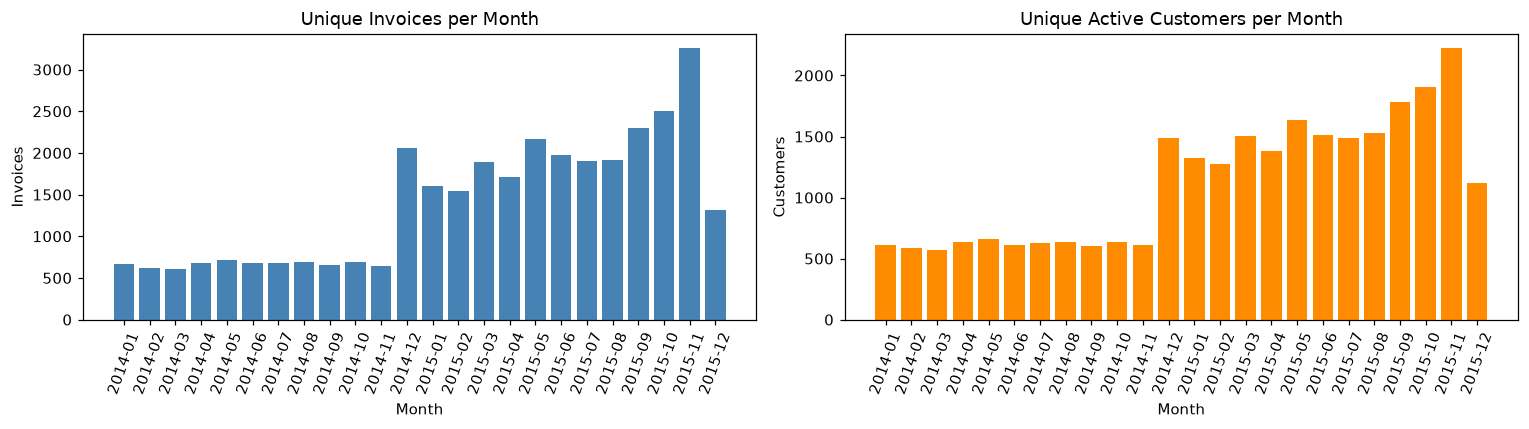

Figure saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

xs = monthly_txns['ym'].astype(str)

axes[0].bar(xs, monthly_txns['invoices'], color='steelblue')
axes[0].set_title('Unique Invoices per Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Invoices')
axes[0].tick_params(axis='x', rotation=70)

axes[1].bar(xs, monthly_txns['customers'], color='darkorange')
axes[1].set_title('Unique Active Customers per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Customers')
axes[1].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_01_monthly_activity.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

## 7. Customer Purchase Frequency Distribution

In [11]:
# Invoices per customer (post-dedup)
cust_inv = purch_clean_temp.groupby('CustomerID')['InvoiceID'].nunique()
print('Invoices per customer — percentile breakdown:')
print(cust_inv.describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(1))
print(f'\nCustomers with only 1 invoice: {(cust_inv == 1).sum():,} ({(cust_inv == 1).mean()*100:.1f}%)')
print(f'Customers with 10+ invoices:   {(cust_inv >= 10).sum():,} ({(cust_inv >= 10).mean()*100:.1f}%)')

Invoices per customer — percentile breakdown:
count    8237.0
mean        4.1
std         5.7
min         1.0
25%         2.0
50%         3.0
75%         5.0
90%         7.0
95%        10.0
99%        22.0
max       210.0
Name: InvoiceID, dtype: float64

Customers with only 1 invoice: 1,843 (22.4%)
Customers with 10+ invoices:   417 (5.1%)


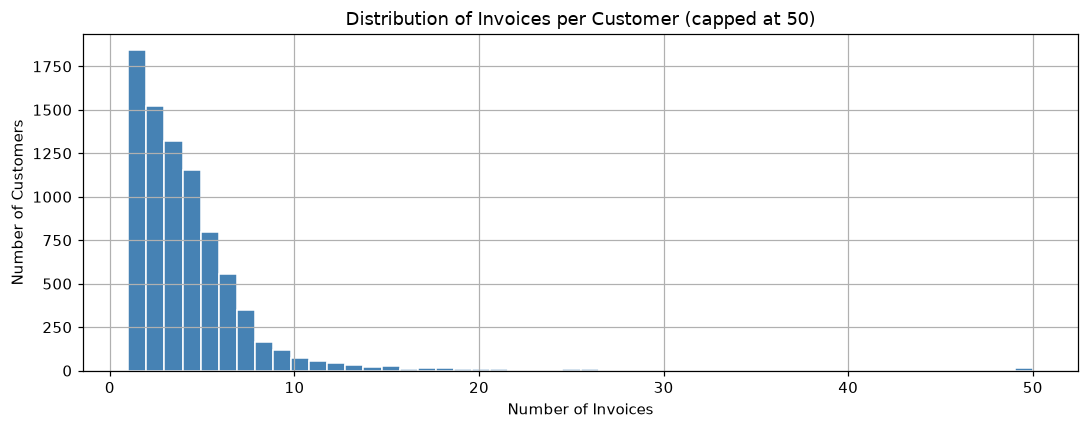

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
capped = cust_inv.clip(upper=50)
capped.hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Invoices per Customer (capped at 50)')
ax.set_xlabel('Number of Invoices')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'fig_02_invoice_freq_dist.png', bbox_inches='tight')
plt.show()

## 8. Revenue Distribution (line_total)

In [13]:
ii_pos = ii[ii['line_total'] > 0].drop_duplicates()
print('line_total summary (positive values only, post-dedup):')
print(ii_pos['line_total'].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(2))

total_revenue = ii_pos['line_total'].sum()
print(f'\nTotal revenue (all 24 months): £{total_revenue:,.2f}')

line_total summary (positive values only, post-dedup):
count    431223.00
mean         21.58
std         296.91
min           0.00
25%           4.95
50%          11.31
75%          19.50
90%          34.50
95%          61.20
99%         183.60
max      168469.60
Name: line_total, dtype: float64

Total revenue (all 24 months): £9,307,314.40


## 9. Product & Category Profile

In [14]:
print('Top 15 categories by number of products:')
print(prod['category'].value_counts().head(15).to_string())
print(f'\nTotal categories: {prod["category"].nunique()}')
print(f'Total products:   {len(prod):,}')

Top 15 categories by number of products:
category
Kitchen & Dining                  863
Home Decor                        758
Apparel & Accessories             642
Stationery & Craft                339
Toys & Games                      330
Health, Beauty & Personal Care    291
Party & Festive                   247
Seasonal                          215
Garden & Outdoor                  160
Miscellaneous                      39
Dairy                              18
Beverages                          17
Administrative                     16
Bakery & Snacks                    16
Produce                            15

Total categories: 25
Total products:   4,033


## 10. Customer Segmentation (customer_type)

In [15]:
ct = cust['customer_type'].value_counts()
print('customer_type distribution:')
for k, v in ct.items():
    print(f'  {k:20s}: {v:5,}  ({v/len(cust)*100:.1f}%)')

customer_type distribution:
  private             : 7,161  (86.9%)
  wholesaler          : 1,076  (13.1%)


## 11. Temporal Window Considerations for Churn Target

> **Note:** No churn target is created here. This section only documents the available date range to inform the cut-off selection in a later phase.

In [16]:
print(f'Full data range:  {purch["date"].min().date()} – {purch["date"].max().date()}')
print(f'Total months:     {(purch["date"].max().year - purch["date"].min().year)*12 + purch["date"].max().month - purch["date"].min().month + 1}')
print()
print('Candidate observation / prediction splits (to be finalised after EDA):')
splits = [
    ('18m obs / 6m pred',  '2015-06-30', '2015-12-30'),
    ('15m obs / 9m pred',  '2015-03-31', '2015-12-30'),
    ('12m obs / 12m pred', '2014-12-31', '2015-12-30'),
]
for label, obs_end, pred_end in splits:
    cust_in_obs = purch[(purch['date'] <= obs_end)]['CustomerID'].nunique()
    cust_in_pred = purch[(purch['date'] > obs_end) & (purch['date'] <= pred_end)]['CustomerID'].nunique()
    print(f'  {label:25s}  obs_end={obs_end}  customers_active_in_obs={cust_in_obs:,}  active_in_pred={cust_in_pred:,}')

Full data range:  2014-01-01 – 2015-12-30
Total months:     24

Candidate observation / prediction splits (to be finalised after EDA):
  18m obs / 6m pred          obs_end=2015-06-30  customers_active_in_obs=6,734  active_in_pred=5,654
  15m obs / 9m pred          obs_end=2015-03-31  customers_active_in_obs=5,782  active_in_pred=6,737
  12m obs / 12m pred         obs_end=2014-12-31  customers_active_in_obs=4,328  active_in_pred=7,534


## 12. Data Understanding Summary

| Finding | Detail |
|---------|--------|
| Total customers | 8,237 |
| Total invoices | 33,499 |
| Transaction line items (raw) | 436,689 |
| Date range | 2014-01-01 – 2015-12-30 (24 months) |
| Missing values | None across all 4 files |
| FK integrity | All relationships valid |
| Duplicates (purchases) | ~5,516 exact rows (will be removed) |
| Duplicates (invoice_items) | ~5,426 exact rows (will be removed) |
| Zero-price rows | Present; retained with flag |
| Churn label | Not yet created |
| Recommended obs cut-off | To be selected post-EDA (Phase 2) |

**Next:** `02_data_cleaning.ipynb` — execute the cleaning pipeline, produce `transactions_clean.csv`, and emit the full cleaning report.